In [9]:
def read_network(path):
    structure = []
    f = open(path, "r")
    n_layers = int(f.readline().strip())
    for _ in range(n_layers):
        structure.append(int(f.readline().strip()))
    f.close()
    return structure

structure = read_network("nn_input.txt")
print("Network structure:", structure)
print(f"  Input layer:  {structure[0]} neurons")
for i in range(1, len(structure) - 1):
    print(f"  Hidden layer {i}: {structure[i]} neurons")
print(f"  Output layer: {structure[-1]} neurons")

Network structure: [2, 2, 1]
  Input layer:  2 neurons
  Hidden layer 1: 2 neurons
  Output layer: 1 neurons


In [10]:
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [11]:
class Neuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, inputs):
        z = sum(w * x for w, x in zip(self.weights, inputs)) + self.bias
        a = sigmoid(z)
        return z, a

In [12]:
class Layer:
    def __init__(self, neurons):
        self.neurons = neurons

    def forward(self, inputs):
        zs = []
        acts = []
        for n in self.neurons:
            z, a = n.forward(inputs)
            zs.append(z)
            acts.append(a)
        return zs, acts

In [13]:
import random

class NeuralNetwork:
    def __init__(self, structure):
        self.structure = structure
        self.layers = []
        for i in range(1, len(structure)):
            n_in = structure[i - 1]
            n_out = structure[i]
            neurons = [Neuron([0.0] * n_in, 0.0) for _ in range(n_out)]
            self.layers.append(Layer(neurons))

    def init_random(self):
        for layer in self.layers:
            for neuron in layer.neurons:
                neuron.weights = [random.random() for _ in neuron.weights]
                neuron.bias = random.random()

    def forward(self, x):
        a = x
        all_z = []
        all_a = [x]
        for layer in self.layers:
            zs, a = layer.forward(a)
            all_z.append(zs)
            all_a.append(a)
        return all_z, all_a

In [14]:
nn = NeuralNetwork(structure)
nn.init_random()
print("Random initialization:")
for l, layer in enumerate(nn.layers):
    for n_idx, neuron in enumerate(layer.neurons):
        print(f"  Layer {l+1}, Neuron {n_idx+1}: w={[round(w, 4) for w in neuron.weights]}, b={round(neuron.bias, 4)}")

Random initialization:
  Layer 1, Neuron 1: w=[0.8197, 0.7736], b=0.7336
  Layer 1, Neuron 2: w=[0.8151, 0.4632], b=0.0742
  Layer 2, Neuron 1: w=[0.5612, 0.9605], b=0.3748


In [ ]:

nn.layers[0].neurons[0].weights = [20.0, 20.0]
nn.layers[0].neurons[0].bias = -10.0
nn.layers[0].neurons[1].weights = [20.0, 20.0]
nn.layers[0].neurons[1].bias = -30.0
nn.layers[1].neurons[0].weights = [20.0, -20.0]
nn.layers[1].neurons[0].bias = -10.0

xor_inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
xor_labels = [0, 1, 1, 0]

print("XOR forward pass:")
print(f"{'x1':>4} {'x2':>4} {'y':>4} {'y_hat':>8} {'pred':>6}")
print("-" * 35)
for x, y in zip(xor_inputs, xor_labels):
    _, all_a = nn.forward(x)
    y_hat = all_a[-1][0]
    pred = 1 if y_hat >= 0.5 else 0
    print(f"{x[0]:>4} {x[1]:>4} {y:>4} {y_hat:>8.4f} {pred:>6}")

XOR forward pass:
  x1   x2    y    y_hat   pred
-----------------------------------
   0    0    0   0.0000      0
   0    1    1   1.0000      1
   1    0    1   1.0000      1
   1    1    0   0.0000      0


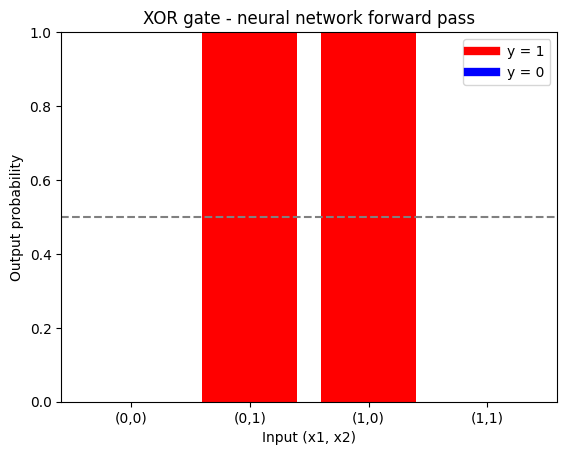

In [16]:
import matplotlib.pyplot as plt

outputs = []
for x in xor_inputs:
    _, all_a = nn.forward(x)
    outputs.append(all_a[-1][0])

labels_str = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]
colors = ["blue" if y == 0 else "red" for y in xor_labels]

plt.bar(labels_str, outputs, color=colors)
plt.axhline(0.5, color="gray", linestyle="--", label="threshold = 0.5")
plt.ylim(0, 1)
plt.xlabel("Input (x1, x2)")
plt.ylabel("Output probability")
plt.title("XOR gate - neural network forward pass")
plt.legend(handles=[
    plt.Line2D([0], [0], color="red", linewidth=6, label="y = 1"),
    plt.Line2D([0], [0], color="blue", linewidth=6, label="y = 0")
])
plt.savefig("neural_network.png")
plt.show()